In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [9]:
data=pd.read_csv('https://robertohincapie.com/data/permanencia_ingenierias.csv', sep=';', encoding='latin_1',decimal=",")
#Modificar la representación de los datos por medio de valores 0 o 1
data=data.replace({'DESERSIÓN':{'SI':1,'NO':0}, 'APOYOS ECONÓMICO EN MATRICULA':{'SI':1,'NO':0}, 'APOYO INSTITUCIONAL':{'SI':1,'NO':0}  })
#Creación de variables dummies para los otros datos
data=pd.get_dummies(data, columns=['ULTIMO ESTADO ACADÉMICO'], prefix='', prefix_sep='', drop_first=False, dtype=int)
data=pd.get_dummies(data, columns=['SEXO'], prefix='SEXO', prefix_sep='_', drop_first=False, dtype=int)
data=data.drop('ALERTASACADEMICAS', axis=1) #Se elimina pues todos los valores son 0

In [10]:
data.head()
#print(len(data.columns))
#data.describe()

,Edad,ALERTASROJAS,ALERTASNARANJAS,ALERTASMANUALES,CAL.PSICOSOCIAL,CAL.FAMILIAR,CAL.SOCIECONOMICO,CAL.ACADEMICO,CRÉDITOS REPROBADOS,CRÉDITOS APROBADOS,...,DESERSIÓN,Advertencia académica,Estado académico normal,Primer reingreso,Segunda suspensión académica,Segundo reingreso,Suspensión académica,SEXO_F,SEXO_M,SEXO_N
0,21,14,17,0,10.31,28.21,22.37,10.61,3,65,...,0,0,1,0,0,0,0,0,1,0
1,21,14,15,0,5.15,28.21,22.37,15.15,15,84,...,0,0,1,0,0,0,0,1,0,0
2,19,13,19,0,8.25,28.21,21.05,15.15,6,8,...,1,1,0,0,0,0,0,1,0,0
3,20,12,18,0,9.28,35.90,15.79,10.61,3,44,...,0,0,1,0,0,0,0,1,0,0
4,20,12,14,0,10.31,17.95,23.68,4.55,0,149,...,0,0,1,0,0,0,0,1,0,0


c:\Users\000010478\Downloads\Curso_TAAE\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\000010478\Downloads\Curso_TAAE\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Factor:  1
- ALERTASNARANJAS->0.8990708321378598
- CAL.ACADEMICO->0.7632859391539436
- ALERTASROJAS->0.7497861879254317
- CAL.PSICOSOCIAL->0.725072074933134
- CAL.FAMILIAR->0.6009462246148132
Factor:  2
- CREDITOS INTENTADOS->0.9623738006395539
- CRÉDITOS APROBADOS->0.8197293168967188
- Edad->0.5632942961790861
- SEXO_N->-0.03865380073322831
Factor:  3
- PROMEDIO GLOBAL->-0.636863004378903
- CRÉDITOS REPROBADOS->0.6298008762286996
- Suspensión académica->0.5269114529094043
- DESERSIÓN->0.4464878728161515
- CRÉDITOS CANCELADOS->0.4373740991818153
- Primer reingreso->0.20560591591774163
- Segunda suspensión académica->0.19386225558848888
- Segundo reingreso->0.07357946604319271
Factor:  4
- SEXO_M->0.992393925258578
- SEXO_F->-0.9848652137299644
Factor:  5
- Advertencia académica->1.005138878082653
- Estado académico normal->-0.7094434229880497
Factor:  6
- CAL.SOCIECONOMICO->0.6173115961494092
- APOYOS ECONÓMICO EN MATRICULA->0.4122463827229264
- APOYO INSTITUCIONAL->0.1755647647105068


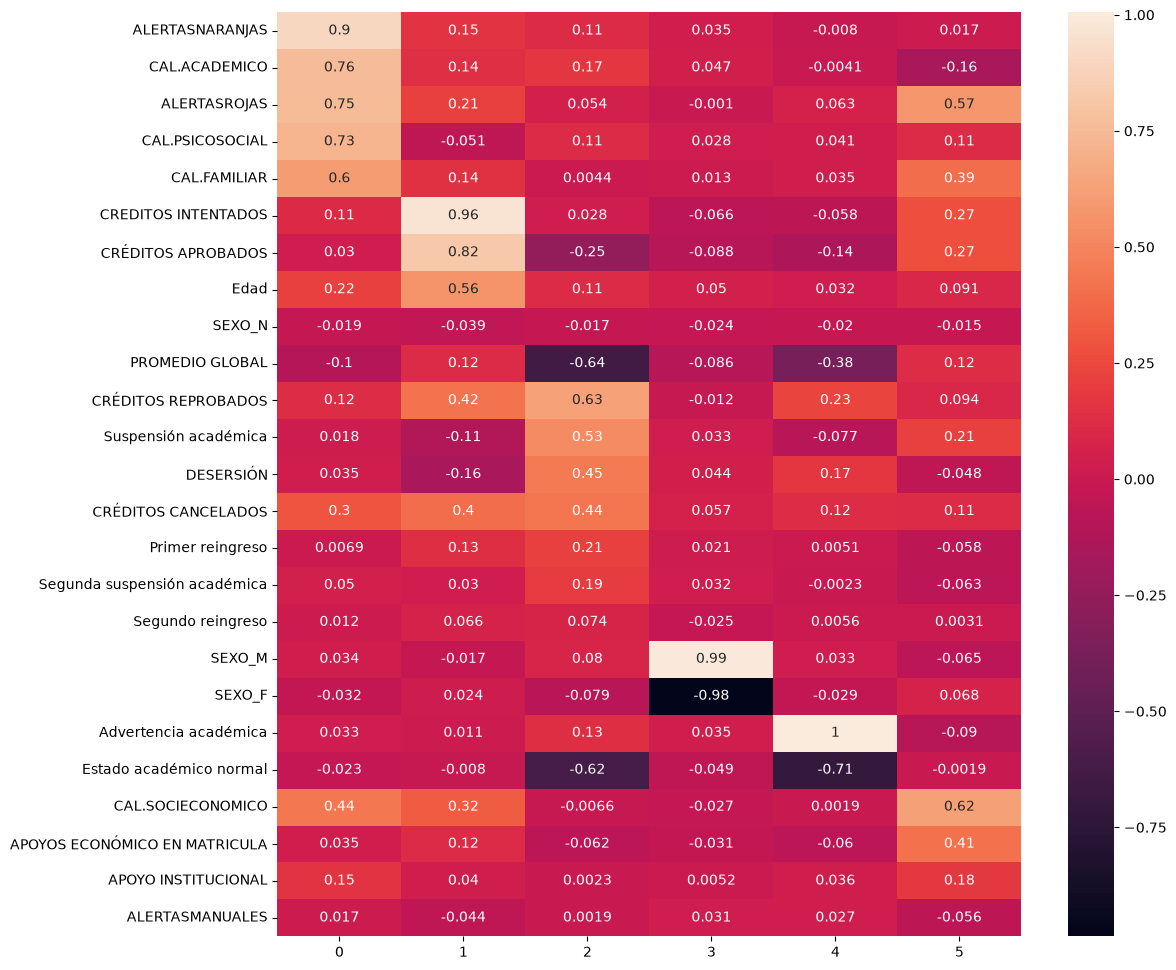

In [15]:
#Desde PCA ya conocemos que podemos trabajar con 3 o 4 componentes.
#Ya tenemos importado decomposition
#from sklearn import decomposition
from factor_analyzer import FactorAnalyzer
N=6
fa=FactorAnalyzer(n_factors=N, rotation='varimax')
fa.fit(data.values)
X2=fa.transform(data.values)

tmp=fa.loadings_
names=list(data.columns)
out=[]
cols=[]
fac=np.argmax(np.abs(tmp), axis=1)
for i in range(N):
  #Análisis del factor i-esimo
  print('Factor: ',i+1)
  tmp2=tmp[fac==i,:]
  names2=[names[int(a)] for a in list(np.where(fac==i)[0])]
  #print(tmp2, names2)
  vmax=np.max(np.abs(tmp2), axis=1)
  ind=np.argsort(-vmax)
  #print(ind)
  for j in range(len(ind)):
    cols.append(names2[ind[j]])
    out.append(tmp2[ind[j]])
    print('- '+names2[ind[j]]+'->'+str(tmp2[ind[j]][np.argmax(np.abs(tmp2[ind[j]]))]))

#for na, va in zip(cols, out):
#  print(na, va)
import seaborn as sns
plt.figure(figsize=(12,12))
sns.heatmap(out, annot=True)
borrar=plt.yticks(ticks=np.arange(len(cols))+0.5, labels=cols, rotation=0)

In [12]:
#datos2=pd.DataFrame(data=X2, columns=['Riesgo','Mal desempeño académico','Antigüedad'])
datos2=pd.DataFrame(data=X2, columns=['Riesgo personal','Mal desempeño académico','Antigüedad'])#, 'Genero','Estado académico','Riesgo económico'])

datos2['Deserción']=data['DESERSIÓN']
datos2

,Riesgo personal,Mal desempeño académico,Antigüedad,Deserción
0,1.823152,-0.714537,0.116367,0
1,1.316373,-0.049612,1.255348,0
2,1.502897,0.895700,-1.085472,1
3,1.526334,-0.772268,0.031715,0
4,0.876920,-0.721487,2.259743,0
...,...,...,...,...
909,-0.681731,0.312807,1.580235,0
910,-0.994963,1.597963,-0.752773,1
911,-0.366301,-0.179380,-0.078945,0
912,-0.048918,-0.667662,-0.976162,0


In [13]:
datos2['Mal desempeño académico']=datos2['Mal desempeño académico']*-1
datos2['Deserción']=datos2['Deserción'].replace({0:'No', 1:'Si'})
datos2.columns=['Riesgo','Desempeño académico','Antigüedad', 'Deserción']
datos2.sample(20)

,Riesgo,Desempeño académico,Antigüedad,Deserción
699,-1.250090,0.316099,0.405186,No
426,0.453035,0.073912,-0.635342,No
138,0.295866,-1.708200,-1.472679,Si
527,0.097566,0.737974,-0.118252,No
633,-0.842619,-1.566713,-1.325527,No
625,-0.174895,-1.401674,-0.166103,No
80,2.680631,-1.149607,1.485329,No
862,0.801668,-1.307924,0.450596,No
618,0.255769,0.159849,-0.417812,No
145,0.178678,0.209768,-0.075218,No


In [14]:
datos2['Size']=1
import plotly.express as px
px.scatter_3d(data_frame=datos2, x='Riesgo', y='Desempeño académico', z='Antigüedad', color='Deserción', size='Size')